In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report 
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv("../data/diabetes_prediction_dataset.csv")

In [67]:
df['gender'] =df['gender'].map({
    "Female": 0,
    "Male" : 1,
    "Other" : -1
})
df['smoking_history'] = df['smoking_history'].map({
    'never' : 0, 'No Info':1, 'current':2, 'former':3, 'ever':4, 'not current':5
})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  int64  
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  int64  
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.9 MB


In [68]:
X,y = df.loc[ :'diabetes' ] , df['diabetes'] 
 

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
y_pred = rf_classifier.predict(X_test)

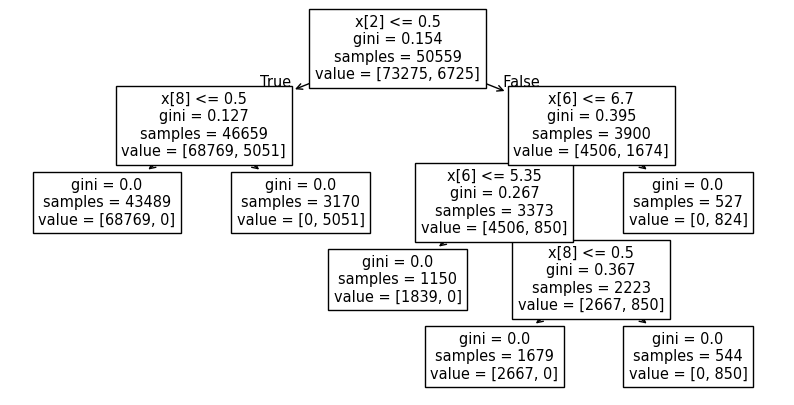

In [73]:
plt.figure(figsize=(10,5))
individual_tree = rf_classifier.estimators_[0]
plot_tree(individual_tree)
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

sample = X_test.iloc[0:1]
prediction = rf_classifier.predict(sample)

sample_dict = sample.iloc[0].to_dict()
print(f"\nSample Paitent: {sample_dict}")
print(f"Predicted Survival: {'Diagnosed With Diabetes' if prediction[0] == 1 else 'Did Not Diagnosed With Diabetes'}")

Accuracy: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18292
           1       1.00      1.00      1.00      1708

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


Sample Passenger: {'gender': 0.0, 'age': 13.0, 'hypertension': 0.0, 'heart_disease': 0.0, 'smoking_history': 1.0, 'bmi': 20.82, 'HbA1c_level': 5.8, 'blood_glucose_level': 126.0, 'diabetes': 0.0}
Predicted Survival: Did Not Survive
